# Inferential Statistics:

 Inferential Statistics is the branch of statistics that uses a sample of data to make conclusions, predictions, or decisions about a larger population. It relies on concepts such as sampling, sampling distribution, and the Central Limit Theorem (CLT) to estimate unknown population parameters. Key tools include point estimation, confidence intervals**, and hypothesis testing, which help quantify uncertainty and assess evidence. Related terms include population, sample, parameter, statistic, standard error,p-value, significance level (α), Type I/II errors, and margin of error, all of which support data-driven decision-making under uncertainty.

# Sampling 

## Overview

Sampling is the process of selecting a subset of observations from a population to make inferences about the entire population.

## Formula

Population Mean:

$$
\mu = \frac{\sum X}{N}
$$

Sample Mean:

$$
\bar{x} = \frac{\sum X}{n}
$$

Standard Error:

$$
SE = \frac{\sigma}{\sqrt{n}}
$$

# Sample Variance

Sample variance measures the spread of sample observations around the sample mean.

### Formula

$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

where,

- $x_i$ = sample observation
- $\bar{x}$ = sample mean
- $n$ = sample size

### Interpretation

- Larger variance $\rightarrow$ data are more dispersed.
- Smaller variance $\rightarrow$ data are closer to the mean.
- Uses $(n-1)$ (Bessel's correction) to estimate population variance.

## Key Insight

As the sample size increases:

* Sample means become normally distributed.
* Variability decreases.
* Estimates become more reliable.


## Objective

Generate a non-normal population, repeatedly draw random samples, and observe how the distribution of sample means becomes approximately normal.


## Interpretation

The population distribution is highly right-skewed and non-normal. However, the distribution of sample means is approximately normal.

This demonstrates the Central Limit Theorem, which forms the foundation of confidence intervals, hypothesis testing, and many machine learning evaluation techniques.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Non-normal population (Exponential Distribution)
population = np.random.exponential(scale=2, size=100000)

# Draw many samples and store sample means
sample_means = []

sample_size = 30
num_samples = 1000

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size)
    sample_means.append(np.mean(sample))

# Visualization
plt.figure(figsize=(12, 5))

# Population Distribution
plt.subplot(1, 2, 1)
sns.histplot(population, bins=50, kde=True)
plt.title("Population Distribution (Non-Normal)")
plt.xlabel("Value")

# Sampling Distribution of Means
plt.subplot(1, 2, 2)
sns.histplot(sample_means, bins=30, kde=True)
plt.title("Sampling Distribution of Means")
plt.xlabel("Sample Mean")

plt.tight_layout()
plt.show()

# Statistics
print(f"Population Mean: {np.mean(population):.2f}")
print(f"Mean of Sample Means: {np.mean(sample_means):.2f}")
print(f"Standard Deviation of Sample Means: {np.std(sample_means):.2f}")

# Central Limit Theorem (CLT)

The Central Limit Theorem states that for a sufficiently large sample size, the sampling distribution of the sample mean approaches a normal distribution, regardless of the population distribution.

### Formula

If

$$
X_1,X_2,\ldots,X_n
$$

are independent observations with population mean $\mu$ and variance $\sigma^2$, then

$$
\bar{X}\sim N\left(\mu,\frac{\sigma^2}{n}\right)
\quad \text{for large } n
$$

### Standardized Form

$$
Z=\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}
\sim N(0,1)
$$

### Key Points

- Sample means tend to follow a normal distribution.
- Accuracy improves as sample size increases.
- Foundation of many statistical inference techniques.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

sample_means = []

for _ in range(1000):
    sample = np.random.exponential(scale=2, size=30)
    sample_means.append(np.mean(sample))

plt.figure(figsize=(8,5))
sns.histplot(sample_means, bins=30, kde=True)

plt.title("Central Limit Theorem")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

# Confidence Intervals & P value

## Overview

A confidence interval provides a range of plausible values for a population parameter based on sample data.
Instead of estimating a single value, we estimate an interval within which the true population mean is likely to lie.

A p-value (probability value) is a statistical measure that helps determine whether the results of an experiment or study are meaningful or likely just occurred by random chance

## Formula

Confidence Interval for Population Mean:

$$
\bar{x} \pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}}
$$

where:

* $\bar{x}$ = Sample Mean
* $\sigma$ = Population Standard Deviation
* $n$ = Sample Size
* $z_{\alpha/2}$ = Critical Z-value

## Key Insight

Higher confidence levels produce wider intervals, while larger sample sizes produce narrower intervals.


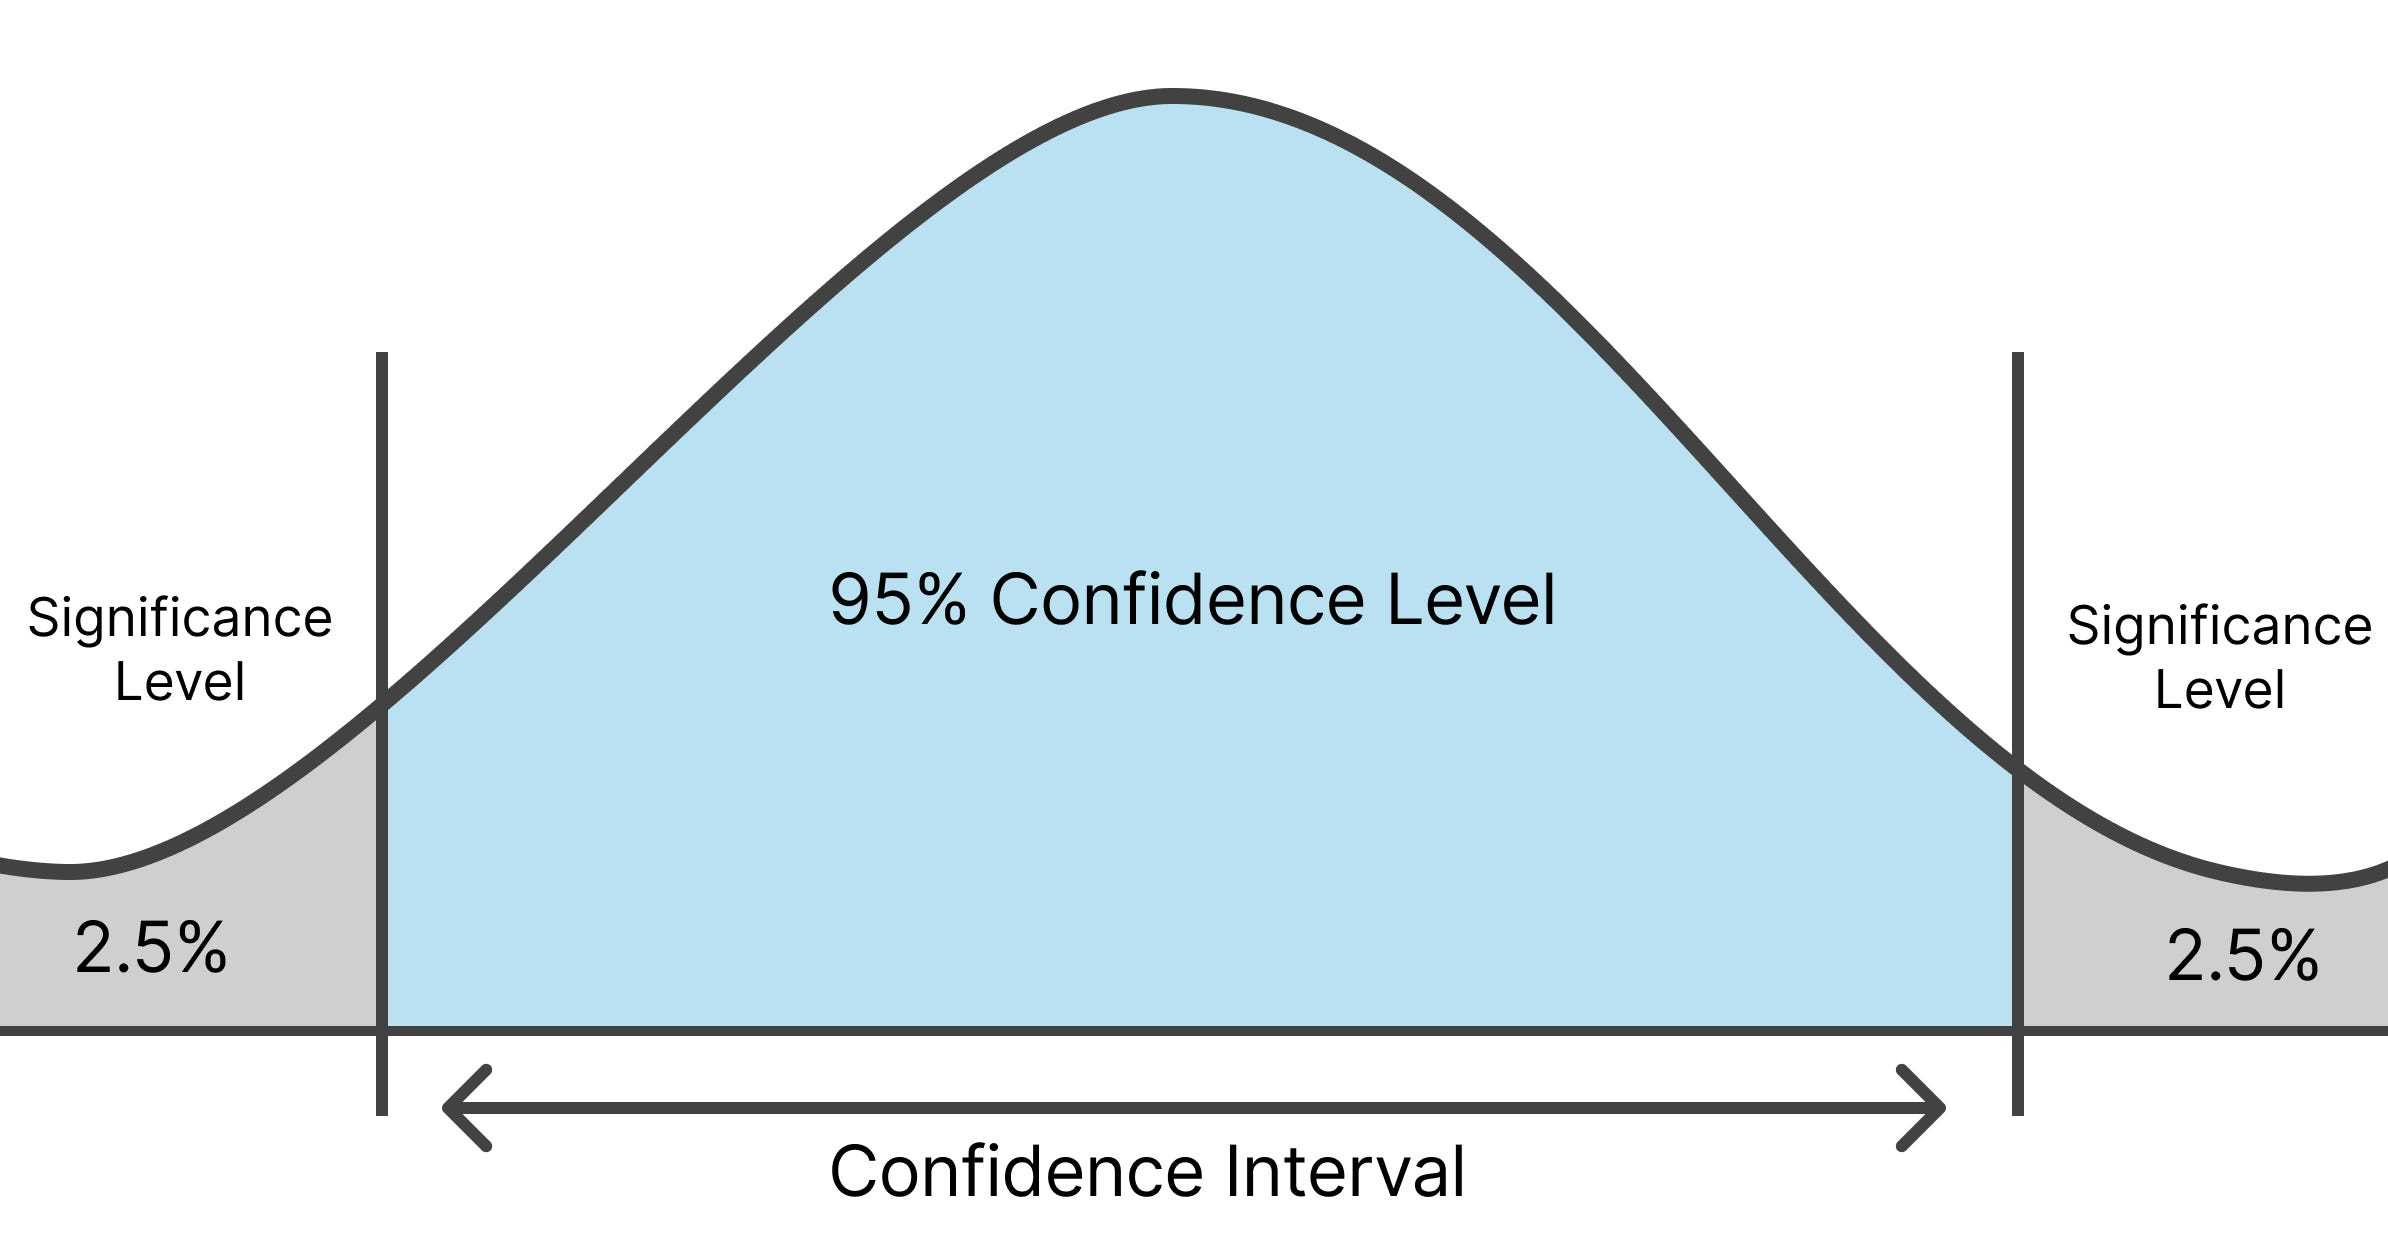

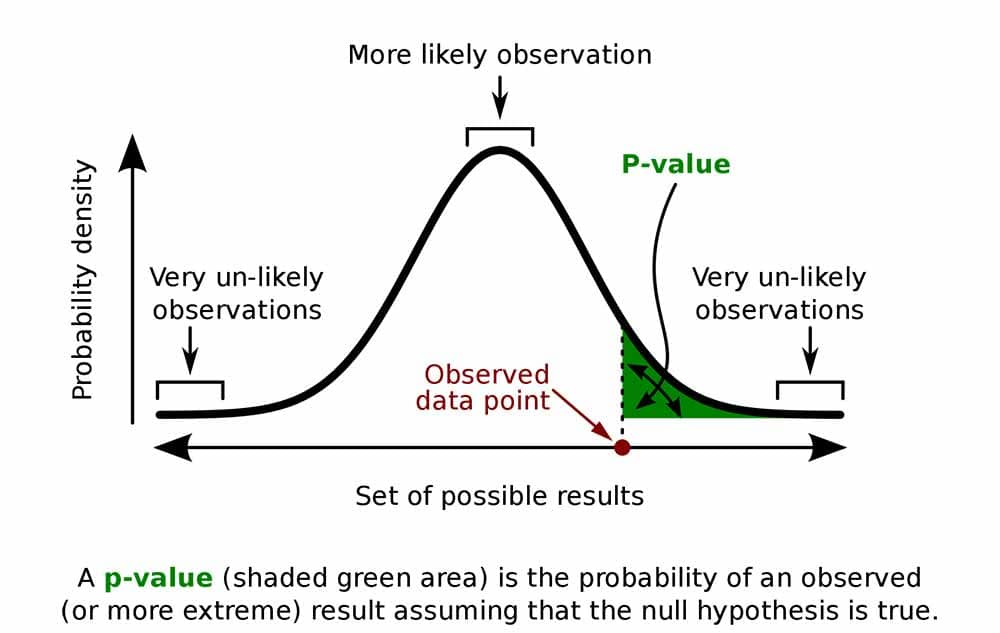

### Objective

Draw a random sample from a population and construct 90%, 95%, and 99% confidence intervals for the population mean.

## Interpretation

The confidence interval provides a range of values that is likely to contain the true population mean.

As the confidence level increases from 90% to 99%, the interval becomes wider because we require greater certainty.

The true population mean is represented by the vertical dashed line and lies within all three confidence intervals.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reproducibility
np.random.seed(42)

# Population
population = np.random.normal(loc=50, scale=10, size=100000)

# Sample
sample = np.random.choice(population, size=100, replace=False)

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
n = len(sample)

# Confidence Levels
confidence_levels = [0.90, 0.95, 0.99]
z_values = [norm.ppf(0.95), norm.ppf(0.975), norm.ppf(0.995)]

intervals = []

for cl, z in zip(confidence_levels, z_values):
    margin_error = z * (sample_std / np.sqrt(n))
    lower = sample_mean - margin_error
    upper = sample_mean + margin_error
    intervals.append((cl, lower, upper))

# Visualization
plt.figure(figsize=(8, 4))

for i, (cl, lower, upper) in enumerate(intervals):
    plt.plot([lower, upper], [i, i], marker='o', linewidth=3)

plt.axvline(np.mean(population), linestyle='--')

plt.yticks(
    range(len(confidence_levels)),
    ['90% CI', '95% CI', '99% CI']
)

plt.xlabel("Mean Value")
plt.title("Confidence Intervals for Population Mean")
plt.grid(True)
plt.show()

# Results
print(f"Population Mean: {np.mean(population):.2f}")
print(f"Sample Mean: {sample_mean:.2f}")

for cl, lower, upper in intervals:
    print(f"{int(cl*100)}% CI: ({lower:.2f}, {upper:.2f})")

## Type I and Type II Errors

When performing ANOVA, decisions are based on sample data and may be incorrect.

### Type I Error (False Positive)

Rejecting the null hypothesis when it is actually true.

$$
P(\text{Type I Error}) = \alpha
$$

Example:

Concluding that teaching methods differ when, in reality, their average performance is the same.

### Type II Error (False Negative)

Failing to reject the null hypothesis when it is actually false.

$$
P(\text{Type II Error}) = \beta
$$

Example:

Concluding that teaching methods do not differ when at least one method truly performs differently.

### Key Insight

* Lowering $\alpha$ reduces the chance of a Type I Error.
* Increasing sample size generally reduces the chance of a Type II Error.
* ANOVA commonly uses $\alpha = 0.05$.


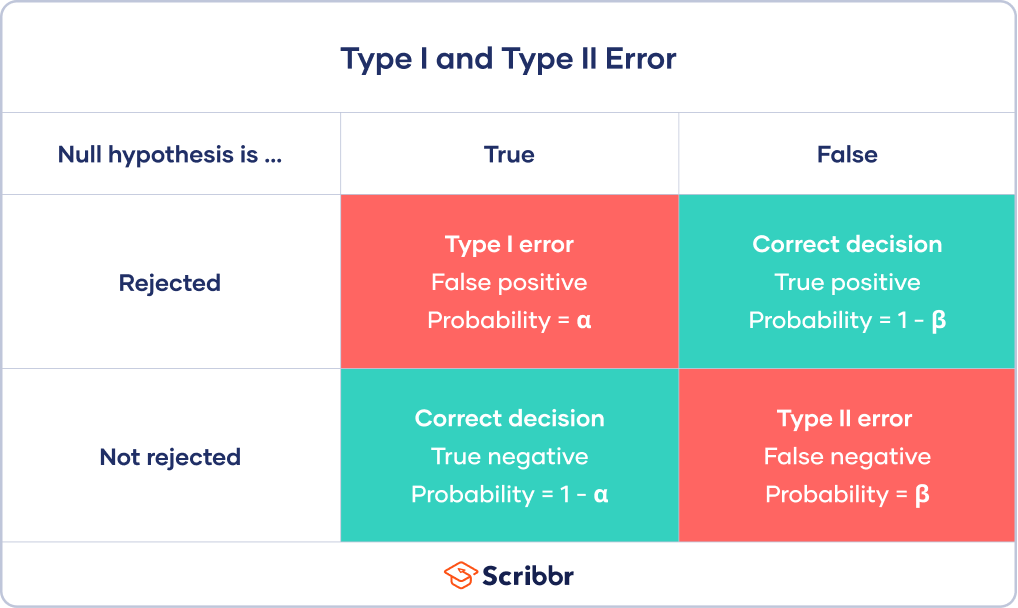

# Common Inferential Statistics Workflow

## Step 1: Define the Population Parameter

Unknown quantity of interest:

$$
\mu,\; p,\; \sigma^2,\; \mu_1-\mu_2,\; p_1-p_2
$$

---

## Step 2: State Hypotheses

### Define Null Hypothesis

$$
H_0
$$

### Alternative Hypothesis

$$
H_1
$$

Examples:

$$
H_0:\mu=\mu_0
$$

$$
H_a:\mu\neq\mu_0
$$

---

## Step 3: Choose Significance Level

$$
\alpha
$$

Common choices:

$$
0.10,\;0.05,\;0.01
$$

---

## Step 4: Compute Sample Estimate

Point estimate from sample:

$$
\bar{x}
$$

$$
\hat{p}
$$

$$
s^2
$$

---

## Step 5: Compute Standard Error

General form:

$$
SE=\frac{\text{Variability}}{\sqrt{n}}
$$

---

## Step 6: Construct Confidence Interval

General form:

$$
\text{Estimate}
\pm
(\text{Critical Value})
\times
SE
$$

Confidence level:

$$
(1-\alpha)\times100\%
$$

---

## Step 7: Calculate Test Statistic

General form:

$$
\text{Test Statistic}
=
\frac{\text{Estimate}-\text{Hypothesized Value}}
{SE}
$$

Examples:

$$
\text{z for Ztest using Z table}
$$

$$
\text{t for Ttest using T table}
$$

$$
\text{chisquare for chisquare Test using chisquare Table} 
$$

$$
\text{F For Ftest/Anova using F table}
$$

---

## Step 8: Determine Critical Value

Based on:

$$
\alpha
$$

and the sampling distribution.

Examples:

$$
z_{\alpha}
,\quad
t_{\alpha}
,\quad
\chi^2_{\alpha}
,\quad
F_{\alpha}
$$

---

## Step 9: Obtain p-value

$$
p\text{-value}
=
P(\text{observing a result at least as extreme as the sample result})
$$

---

## Step 10: Make Decision

### Using p-value

If

$$
p\text{-value} < \alpha
$$

Reject:

$$
H_0
$$

Otherwise:

$$
\text{Fail to Reject } H_0
$$

### Using Critical Value

If

$$
\text{Test Statistic}
\in
\text{Rejection Region}
$$

Reject:

$$
H_0
$$

Otherwise:

$$
\text{Fail to Reject } H_0
$$

---

# Core Components Used in Most Inferential Procedures

$$
H_0
\rightarrow
H_a
\rightarrow
\alpha
\rightarrow
\text{Estimate}
\rightarrow
SE
\rightarrow
\text{Test Statistic}
\rightarrow
\text{Critical Value / p-value}
\rightarrow
\text{Decision}
\rightarrow
\text{Inference}
$$

# Hypothesis Testing Fundamentals (Z-Test)

## Overview

Hypothesis testing is a statistical method used to determine whether there is enough evidence in a sample to support a claim about a population.

## Hypotheses

Null Hypothesis:

$$
H_0:\mu=\mu_0
$$

Alternative Hypothesis:

$$
H_1:\mu\neq\mu_0
$$

## Test Statistic

$$
Z=\frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}
$$

- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean
- $\sigma$ = Population Standard Deviation
- $n$ = Sample Size

## Key Insight

If the p-value is smaller than the significance level ($\alpha$), we reject the null hypothesis.


### Objective

Test whether the average score of a class differs significantly from a claimed population mean using a one-sample Z-Test.

## Interpretation

The sample mean is compared with the claimed population mean using a Z-Test.

The p-value measures the strength of evidence against the null hypothesis.

Decision Rule:

* If p-value < 0.05, reject $H_0$
* If p-value ≥ 0.05, fail to reject $H_0$

A small p-value indicates that the observed sample result is unlikely under the null hypothesis.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reproducibility
np.random.seed(42)

# Claimed population mean
mu_0 = 70

# Sample data
sample = np.random.normal(loc=74, scale=10, size=50)

# Known population standard deviation
sigma = 10

# Sample statistics
x_bar = np.mean(sample)
n = len(sample)

# Z-statistic
z = (x_bar - mu_0) / (sigma / np.sqrt(n))

# Two-tailed p-value
p_value = 2 * (1 - norm.cdf(abs(z)))

# Visualization
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(8,5))
plt.plot(x, y)

plt.axvline(z, linestyle='--')

plt.title("Z-Test Statistic on Standard Normal Distribution")
plt.xlabel("Z Score")
plt.ylabel("Density")

plt.grid(True)
plt.show()

# Results
alpha = 0.05

print(f"Sample Mean: {x_bar:.2f}")
print(f"Z Statistic: {z:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

# Hypothesis Testing Fundamentals (T-Test)
## When to Use a t-Test?

A t-test is a specific type of hypothesis test used when:

* The population standard deviation is unknown.
* The sample size is relatively small.
* The objective is to compare means.

Examples:

* Comparing average marks before and after a new teaching method.
* Comparing average salaries of two groups.
* Comparing average product ratings.

In practice, most real-world mean comparisons use t-tests because the population standard deviation is rarely known.

## Hypotheses

Null Hypothesis:

$$
H_0:\mu=\mu_0
$$

Alternative Hypothesis:

$$
H_1:\mu\neq\mu_0
$$

## Test Statistic

$$
t = \frac{\bar{x} - \mu}{s/\sqrt{n}}
$$

- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean (Claimed Mean)
- $s$ = Sample Standard Deviation
- $n$ = Sample Size

### Objective

Test whether the average exam score of students is significantly different from a claimed population mean.

## Interpretation

The sample mean is compared against the claimed population mean using a statistical test.

If the p-value is less than the significance level ($\alpha = 0.05$), the null hypothesis is rejected.

Otherwise, there is insufficient evidence to conclude that the population mean differs from the claimed value.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# Reproducibility
np.random.seed(42)

# Sample exam scores
scores = np.random.normal(loc=78, scale=8, size=40)

# Claimed population mean
population_mean = 75

# One-Sample Hypothesis Test
t_statistic, p_value = ttest_1samp(scores, population_mean)

# Visualization
plt.figure(figsize=(8, 4))

sns.histplot(scores, bins=10, kde=True)

plt.axvline(np.mean(scores), linestyle='--', label='Sample Mean')
plt.axvline(population_mean, linestyle=':', label='Claimed Mean')

plt.title("Sample Scores Distribution")
plt.xlabel("Exam Score")
plt.legend()

plt.show()

# Results
print(f"Sample Mean: {np.mean(scores):.2f}")
print(f"Claimed Population Mean: {population_mean}")
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

# Chi-Square Test(Chi-Square Distribution)

## Overview

The Chi-Square Test is used to determine whether there is a significant association between two categorical variables.

It compares observed frequencies with expected frequencies under the assumption of independence.

## Formula

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

where:

* $O$ = Observed Frequency
* $E$ = Expected Frequency

## Key Insight

A small p-value indicates that the variables are likely associated and not independent.


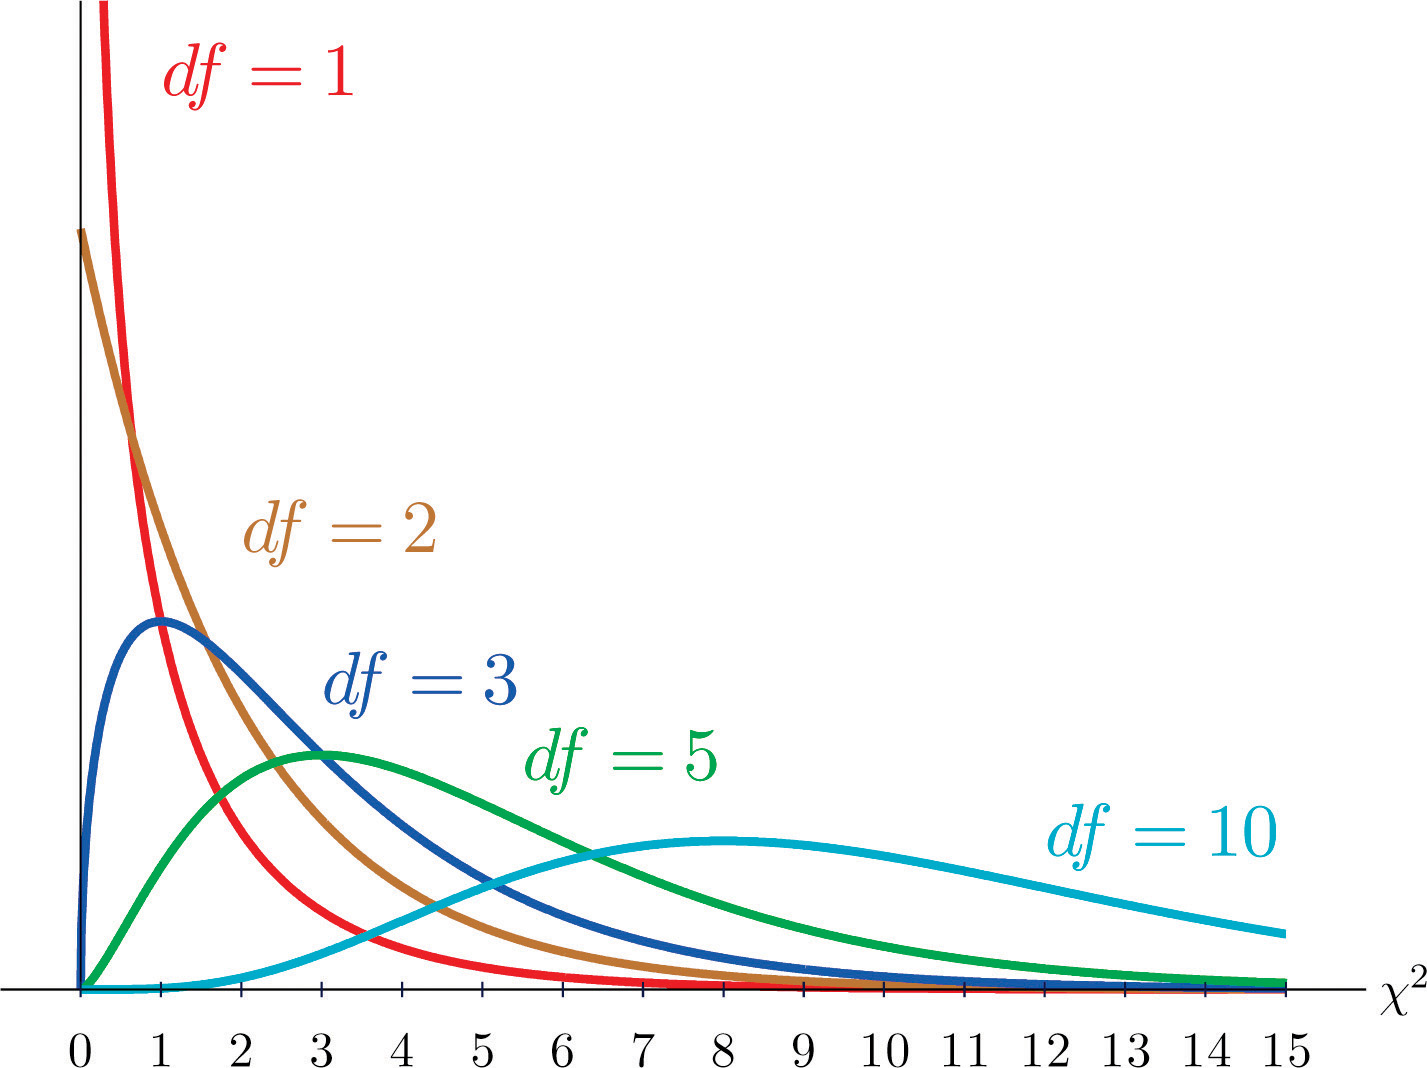

### Objective

Determine whether gender and product preference are independent using a Chi-Square Test of Independence.

## Interpretation

The Chi-Square Test compares observed frequencies with frequencies expected under independence.

* If p-value < 0.05, reject the null hypothesis.
* If p-value ≥ 0.05, fail to reject the null hypothesis.

In this example, a small p-value suggests that product preference may depend on gender, indicating an association between the two variables.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Contingency Table
data = pd.DataFrame({
    'Product_A': [40, 20],
    'Product_B': [10, 30]
}, index=['Male', 'Female'])

print("Contingency Table:")
print(data)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(data)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Expected Frequencies
expected_df = pd.DataFrame(
    expected,
    index=data.index,
    columns=data.columns
)

print("\nExpected Frequencies:")
print(expected_df)

# Visualization
plt.figure(figsize=(6,4))
sns.heatmap(
    data,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Observed Frequencies")
plt.show()

# Analysis of Variance (ANOVA)(F Distribution)

## Overview

ANOVA is used to determine whether the means of three or more groups are significantly different.

Instead of performing multiple t-tests, ANOVA evaluates all groups simultaneously while controlling the overall error rate.

## Formula

F-Statistic:

$$
F = \frac{\text{Between-Group Variability}}{\text{Within-Group Variability}}
$$

## Hypotheses

Null Hypothesis:

$$
H_0:\ \mu_1 = \mu_2 = \mu_3
$$

Alternative Hypothesis:

$$
H_a:\ \text{At least one group mean differs}
$$

## Key Insight

A large F-statistic and a small p-value indicate that at least one group mean is significantly different from the others.


### Objective

Compare the average scores of students taught using three different teaching methods and determine whether the teaching methods produce significantly different outcomes.

## Interpretation

The boxplot shows the distribution of scores for each teaching method.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that at least one group mean differs significantly.

If the p-value is greater than 0.05, there is insufficient evidence to conclude that the teaching methods produce different average scores.

## Key Takeaways

* ANOVA compares the means of three or more groups.
* The F-statistic measures between-group variation relative to within-group variation.
* A small p-value suggests a significant difference among group means.
* ANOVA identifies whether a difference exists, but not which specific groups differ.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Reproducibility
np.random.seed(42)

# Sample data
method_A = np.random.normal(70, 5, 30)
method_B = np.random.normal(75, 5, 30)
method_C = np.random.normal(82, 5, 30)

# ANOVA Test
f_statistic, p_value = f_oneway(method_A, method_B, method_C)

print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.6f}")

# Create DataFrame
df = pd.DataFrame({
    "Score": np.concatenate([method_A, method_B, method_C]),
    "Method": ["A"] * 30 + ["B"] * 30 + ["C"] * 30
})

# Visualization
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Method", y="Score")

plt.title("Comparison of Scores Across Teaching Methods")
plt.xlabel("Teaching Method")
plt.ylabel("Score")
plt.show()

# F-Distribution and F-Test

## Overview

The F-distribution is a continuous probability distribution used to compare variances and perform hypothesis testing in ANOVA.

It is positively skewed and depends on two degrees of freedom:

* Numerator Degrees of Freedom ($df_1$)
* Denominator Degrees of Freedom ($df_2$)

## Formula

F-Statistic:

$$
F = \frac{s_1^2}{s_2^2}
$$

where:

* $s_1^2$ = First Sample Variance
* $s_2^2$ = Second Sample Variance

## Key Insight

* $F \approx 1$ suggests similar variances.
* Large F-values suggest greater differences between variances.
* ANOVA uses the F-statistic to compare multiple group means.


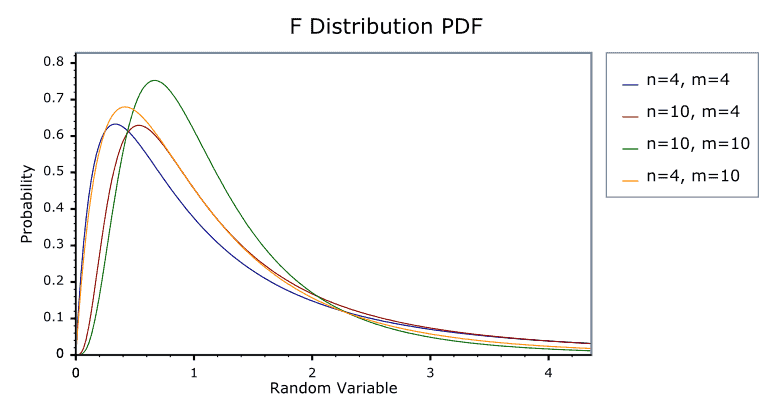

### Objective

Visualize the F-distribution and perform an F-test to compare the variances of two samples.

## Interpretation

The F-test compares the variances of two populations.

* If the p-value is less than 0.05, we reject the null hypothesis and conclude that the variances differ significantly.
* If the p-value is greater than 0.05, there is insufficient evidence to conclude that the variances are different.

The F-distribution serves as the theoretical foundation for ANOVA and other variance-based statistical tests.

## Key Takeaways

* The F-distribution is right-skewed and non-negative.
* The F-statistic is a ratio of variances.
* F-tests are used to compare variances.
* ANOVA extends the concept of the F-test to compare multiple group means.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Degrees of Freedom
df1 = 5
df2 = 20

# Generate F-distribution values
x = np.linspace(0, 5, 1000)
y = f.pdf(x, df1, df2)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, y)

plt.title(f"F-Distribution (df1={df1}, df2={df2})")
plt.xlabel("F Value")
plt.ylabel("Density")
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
from scipy.stats import f

# Reproducibility
np.random.seed(42)

# Two samples
sample1 = np.random.normal(50, 10, 30)
sample2 = np.random.normal(50, 15, 30)

# Variances
var1 = np.var(sample1, ddof=1)
var2 = np.var(sample2, ddof=1)

# F Statistic
f_stat = var1 / var2

# Degrees of Freedom
df1 = len(sample1) - 1
df2 = len(sample2) - 1

# Two-tailed p-value
p_value = 2 * min(
    f.cdf(f_stat, df1, df2),
    1 - f.cdf(f_stat, df1, df2)
)

print(f"Variance Sample 1 : {var1:.2f}")
print(f"Variance Sample 2 : {var2:.2f}")
print(f"F Statistic       : {f_stat:.4f}")
print(f"P-value           : {p_value:.4f}")

# Summary and Key Takeaways

This project explored the core concepts of inferential statistics using Python and statistical visualization.

The workflow followed a natural progression:

$$
\text{Population}
\rightarrow
\text{Sampling}
\rightarrow
\text{CLT}
\rightarrow
\text{Confidence Intervals}
\rightarrow
\text{Hypothesis Testing}
\rightarrow
\text{Statistical Tests}
$$

## Topics Covered

* Sampling and Central Limit Theorem (CLT)
* Confidence Intervals
* Hypothesis Testing
* One-Sample t-Test
* Independent t-Test
* Chi-Square Test
* Analysis of Variance (ANOVA)
* F distribution and F test

## Key Learnings

* Samples can be used to make inferences about populations.
* The Central Limit Theorem enables statistical inference.
* Confidence intervals quantify estimation uncertainty.
* Hypothesis testing provides a framework for decision-making.
* p-values help evaluate evidence against the null hypothesis.
* Different statistical tests are suited to different data types and problems.

## Conclusion

Inferential statistics forms the foundation of exploratory data analysis, feature engineering, machine learning evaluation, A/B testing, and data-driven decision making.
